# DynamicBind 虚拟筛选教程

对应书稿章节：3.2.3 柔性对接（配体与残基联合扩散建模）。
教学数据：使用 `demo_data/CoreSet.dat` 中的 20 个代表性复合物子集，不等同于完整 CASF-2016 core set。

本 notebook 只保留 **配体 + 残基多路分数预测** 这条技术路线，并以 DynamicBind 原始仓库
（`Chapter3/docking/raw/flexible-docking/DynamicBind/`）的默认超参数为基准。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`（**不引入 e3nn / ESM / Kabsch 对齐**，教学精简版）
- 噪声调度公式与原始 `utils/diffusion_utils.py::t_to_sigma` 对齐
- 反向采样更新与原始 `utils/sampling.py` ODE 分支对齐
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `RMSD < 2A`

**已做的教学代理（原论文用不同数学对象，此处用欧氏代理以保持 Linear+ReLU 骨架）**：
- 旋转 score：原论文在 SO(3) 上用 IGSO(3) 预计算表；此处用 `axis*angle` 向量 + 欧氏 `-noise/σ²`
- 扭转 score：原论文在 torus 上用 wrapped Gaussian；此处用随机单根可旋转键 + 标量欧氏代理
- chi1 角：原论文为 N-CA-CB-CG 二面角；此处用 `arctan2` 在 xy 平面的投影代理

### 教学版已去掉的 raw DynamicBind 组件

为了保持 `nn.Linear() + nn.ReLU()` 骨架并让本 notebook 在 CPU 上几分钟内就能跑完，以下 raw 模块**被静默移除**，只保留 6-way 分数头：

- **ESM-2 language-model embeddings (1280 维)**：raw 把每个残基的 ESM-2 表示拼到残基特征上（`models/score_model.py::ReceptorEncoder`）。本 notebook 只用 21 维 one-hot 残基类型。
- **LDDT confidence head**：raw 额外训练一个头预测残基级 plDDT 置信度（`utils/training.py` 的 `lddt_loss`）。本 notebook 不预测置信度。
- **Affinity head**：raw 在 finetune 阶段启用亲和力回归头（`utils/training.py` 的 `affinity_loss`）。本 notebook 不做亲和力回归，只做位姿预测。
- **e3nn TensorProductConv + IGSO(3) 预计算表**：raw 用 e3nn 等变卷积 + `so3.expansion` 查表抽旋转 score；本 notebook 用欧氏 `axis·angle` 向量 + MLP 代理，仅保留与原始 loss 量级一致的训练/推理接口。

因此 notebook 的定位是「让读者读懂 6-way score matching 如何训练+推理」，而不是复现 raw DynamicBind 的最终 RMSD 指标。


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.spatial import distance_matrix
from rdkit import RDLogger
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, RESIDUE_FEAT_DIM, SinusoidalEmbedding,
    atom_features, build_mlp, compute_rmsd, describe_model_parameters,
    extract_residue_data, history_frame, load_complex,
    metric_frame, parse_coreset, plot_loss_curves, residue_features,
)
from teaching_demos.common import so3, torus
from teaching_demos.common import training as _training
from teaching_demos.common import (
    Channel,
    axis_angle_to_matrix,
    get_rotatable_bonds,
    manifold_score_loss,
    modify_torsion_angles,
    randomize_position_pocket,
    reverse_diffusion_loop,
    t_to_sigma_individual,
)


## 1. 超参数设置

DynamicBind 使用 **6-way 分数匹配**，配体和残基采用不同的噪声调度策略：

| 参数 | 含义 | 原始默认值 |
|------|------|-----------|
| `SIGMA_TR_MIN/MAX`  | 配体平移 σ（exponential `σ_min^(1-t)·σ_max^t`） | 0.1 / 20 Å |
| `SIGMA_ROT_MIN/MAX` | 配体旋转 σ | 0.03 / 1.65 rad |
| `SIGMA_TOR_MIN/MAX` | 配体扭转 σ | 0.0314 / π rad |
| `SIGMA_RES_*_MIN/MAX` | 残基 σ（power-law `σ_min + (σ_max−σ_min)(5t)^0.3`） | 0.01 / 1 |
| `N_INTERACTION_LAYERS` | 交互层迭代次数（原论文 2 层 TensorProductConv） | 2 |

残基使用更保守的噪声，体现物理直觉：蛋白骨架运动受到更多约束。


In [2]:
HIDDEN_DIM = 128
N_INTERACTION_LAYERS = 2              # 与原始 num_conv_layers=2 对齐
DISTANCE_CUTOFF = 80.0              # 与原始 cross_max_distance=80 对齐（parsing.py:94）
N_EPOCHS = 200
LR = 1e-4
BATCH_SIZE = 1
N_STEPS = 20
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 配体噪声 (exponential 调度, σ_min^(1-t) · σ_max^t)
SIGMA_TR_MIN,  SIGMA_TR_MAX  = 0.1,    20.0
SIGMA_ROT_MIN, SIGMA_ROT_MAX = 0.03,   1.65
SIGMA_TOR_MIN, SIGMA_TOR_MAX = 0.0314, 3.14  # 与 raw parsing.py:75 默认值对齐（原仓库使用 3.14，非 π）

# 残基噪声 (power-law 调度, σ_min + (σ_max-σ_min)·(5t)^0.3, 与原始一致)
SIGMA_RES_TR_MIN,  SIGMA_RES_TR_MAX  = 0.01, 1.0
SIGMA_RES_ROT_MIN, SIGMA_RES_ROT_MAX = 0.01, 1.0
SIGMA_RES_CHI_MIN, SIGMA_RES_CHI_MAX = 0.01, 1.0

# 损失权重 (与原始 parsing.py 对齐: 6 路均 0.33)
W_TR = W_ROT = W_TOR = 0.33
W_RES_TR = W_RES_ROT = W_RES_CHI = 0.33

torch.manual_seed(SEED)
np.random.seed(SEED)

display(pd.DataFrame({
    "参数":  ["DEVICE", "扩散模式",
              "配体平移 σ [min,max]", "配体旋转 σ [min,max]", "配体扭转 σ [min,max]",
              "残基平移 [min,max]", "残基旋转 [min,max]", "残基 chi [min,max]",
              "HIDDEN_DIM", "N_INTERACTION_LAYERS", "DISTANCE_CUTOFF", "N_EPOCHS", "LR"],
    "值": [str(DEVICE), "6-way (lig tr+rot+tor, res tr+rot+chi)",
           f"[{SIGMA_TR_MIN}, {SIGMA_TR_MAX}] Å",
           f"[{SIGMA_ROT_MIN}, {SIGMA_ROT_MAX}] rad",
           f"[{SIGMA_TOR_MIN:.4f}, {SIGMA_TOR_MAX:.4f}] rad",
           f"[{SIGMA_RES_TR_MIN}, {SIGMA_RES_TR_MAX}] Å",
           f"[{SIGMA_RES_ROT_MIN}, {SIGMA_RES_ROT_MAX}] rad",
           f"[{SIGMA_RES_CHI_MIN}, {SIGMA_RES_CHI_MAX}] rad",
           str(HIDDEN_DIM), str(N_INTERACTION_LAYERS), f"{DISTANCE_CUTOFF} Å",
           str(N_EPOCHS), str(LR)],
}))


,参数,值
0,DEVICE,cuda
1,扩散模式,"6-way (lig tr+rot+tor, res tr+rot+chi)"
2,"配体平移 σ [min,max]","[0.1, 20.0] Å"
3,"配体旋转 σ [min,max]","[0.03, 1.65] rad"
4,"配体扭转 σ [min,max]","[0.0314, 3.1400] rad"
5,"残基平移 [min,max]","[0.01, 1.0] Å"
6,"残基旋转 [min,max]","[0.01, 1.0] rad"
7,"残基 chi [min,max]","[0.01, 1.0] rad"
8,HIDDEN_DIM,128
9,N_INTERACTION_LAYERS,2


## 2. 数据加载与特征提取

DynamicBind 需要：
- **配体**：原子特征 (10 维) + 3D 坐标，由 `load_complex()` + `atom_features()` 提取
- **蛋白残基**：残基特征 (21 维) + CA 坐标，由 `extract_residue_data()` 提取
- **侧链 chi1 角度**：用 CA→CB 方向向量在 xy 平面的投影角作为代理值

此外还有 DynamicBind 专有的扩散工具函数：
- `t_to_sigma_6way()`: 6-way 噪声调度（配体 exponential，残基 power-law）
- `apply_noise_to_ligand()`: 配体 3-way 加噪
- `apply_noise_to_residues()`: 残基 3-way 加噪（DynamicBind 新增）

In [3]:
import os
from collections import deque
from Bio.PDB import PDBParser
from rdkit import Chem


def extract_residue_data_with_cb(pocket_pdb):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pocket", pocket_pdb)
    res_feats_list, ca_list, cb_list, n_list, c_list = [], [], [], [], []
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[0] != " " or "CA" not in residue:
                    continue
                if "N" not in residue or "C" not in residue:
                    continue
                resname = residue.get_resname().strip()
                ca = residue["CA"].get_vector().get_array().astype(np.float32)
                n  = residue["N"].get_vector().get_array().astype(np.float32)
                c  = residue["C"].get_vector().get_array().astype(np.float32)
                cb = residue["CB"].get_vector().get_array().astype(np.float32) if "CB" in residue else ca.copy()
                res_feats_list.append(residue_features(resname))
                ca_list.append(ca); cb_list.append(cb)
                n_list.append(n);   c_list.append(c)
        break
    return (np.array(res_feats_list, dtype=np.float32),
            np.array(ca_list, dtype=np.float32),
            np.array(cb_list, dtype=np.float32),
            np.array(n_list,  dtype=np.float32),
            np.array(c_list,  dtype=np.float32))


def extract_chi1_angles(ca_coords, cb_coords):
    diff = cb_coords - ca_coords
    norms = np.linalg.norm(diff, axis=1, keepdims=True).clip(1e-6)
    direction = diff / norms
    return np.arctan2(direction[:, 1], direction[:, 0]).astype(np.float32)


TR_RANGE      = (SIGMA_TR_MIN,      SIGMA_TR_MAX)
ROT_RANGE     = (SIGMA_ROT_MIN,     SIGMA_ROT_MAX)
TOR_RANGE     = (SIGMA_TOR_MIN,     SIGMA_TOR_MAX)
RES_TR_RANGE  = (SIGMA_RES_TR_MIN,  SIGMA_RES_TR_MAX)
RES_ROT_RANGE = (SIGMA_RES_ROT_MIN, SIGMA_RES_ROT_MAX)
RES_CHI_RANGE = (SIGMA_RES_CHI_MIN, SIGMA_RES_CHI_MAX)


def t_to_sigma_6way(t):
    sigma_tr  = t_to_sigma_individual(t, "exponential", *TR_RANGE)
    sigma_rot = t_to_sigma_individual(t, "exponential", *ROT_RANGE)
    sigma_tor = t_to_sigma_individual(t, "exponential", *TOR_RANGE)
    def pl(mn, mx): return min(mn + (mx - mn) * (t * 5.0) ** 0.3, mx)
    return (sigma_tr, sigma_rot, sigma_tor,
            pl(*RES_TR_RANGE), pl(*RES_ROT_RANGE), pl(*RES_CHI_RANGE))


def apply_noise_to_ligand(lig_coords, mol, rotatable_bonds, t):
    sigma_tr, sigma_rot, sigma_tor = t_to_sigma_6way(t)[:3]

    rot_vec = so3.sample_vec(float(sigma_rot)).astype(np.float32)
    R = axis_angle_to_matrix(rot_vec)
    centroid = lig_coords.mean(0, keepdims=True)
    rotated = (lig_coords - centroid) @ R.T + centroid

    noise_tr = np.random.randn(3).astype(np.float32) * sigma_tr
    noisy = rotated + noise_tr

    # 教学简化：每次只扰动随机选 1 根可旋转键，tor_noise 和 tor_target 都是单标量
    # （与 DiffDock-Pocket 一致；raw DynamicBind 是逐键并行扰动）
    if len(rotatable_bonds) > 0:
        bond_idx = int(np.random.randint(len(rotatable_bonds)))
        sigma_arr = np.array([sigma_tor], dtype=np.float64)
        tor_noise_scalar = float(torus.sample(sigma_arr)[0])
        noisy = modify_torsion_angles(
            noisy, mol, [rotatable_bonds[bond_idx]],
            np.array([tor_noise_scalar], dtype=np.float32),
        )
        tor_target = np.float32(torus.score(np.array([tor_noise_scalar]), sigma_arr)[0])
    else:
        tor_target = np.float32(0.0)

    tr_target  = (-noise_tr / (sigma_tr ** 2 + 1e-8)).astype(np.float32)
    rot_target = so3.score_vec(float(sigma_rot), rot_vec).astype(np.float32)
    return noisy.astype(np.float32), tr_target, rot_target, tor_target


def apply_noise_to_residues(ca_coords, n_coords, c_coords, chi1_angles, t):
    _, _, _, sigma_res_tr, sigma_res_rot, sigma_res_chi = t_to_sigma_6way(t)
    n_res = len(ca_coords)

    noise_tr = np.random.randn(n_res, 3).astype(np.float32) * sigma_res_tr

    noise_rot = np.zeros((n_res, 3), dtype=np.float32)
    rot_target = np.zeros((n_res, 3), dtype=np.float32)
    for i in range(n_res):
        rv = so3.sample_vec(float(sigma_res_rot)).astype(np.float32)
        noise_rot[i] = rv
        rot_target[i] = so3.score_vec(float(sigma_res_rot), rv).astype(np.float32)

    sigmas_chi = np.full(n_res, sigma_res_chi, dtype=np.float64)
    noise_chi = torus.sample(sigmas_chi).astype(np.float32)
    # raw DynamicBind utils/training.py:142-145 applies cosine-distance directly
    # between predicted chi delta and the noise angle (no torus.score transform).
    chi_target = noise_chi.astype(np.float32)

    noisy_ca = ca_coords + noise_tr
    noisy_n  = n_coords  + noise_tr
    noisy_c  = c_coords  + noise_tr
    for i in range(n_res):
        R = axis_angle_to_matrix(noise_rot[i])
        noisy_n[i] = R @ (noisy_n[i] - noisy_ca[i]) + noisy_ca[i]
        noisy_c[i] = R @ (noisy_c[i] - noisy_ca[i]) + noisy_ca[i]
    noisy_chi1 = np.arctan2(np.sin(chi1_angles + noise_chi), np.cos(chi1_angles + noise_chi))

    # L1 损失使用 raw target = -noise（非 -noise/σ²），匹配 utils/training.py:128-131
    tr_target = (-noise_tr).astype(np.float32)
    return (noisy_ca, noisy_n, noisy_c, noisy_chi1,
            tr_target, rot_target, chi_target)


labels = parse_coreset(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(labels)} 个复合物")

all_data = []
for pdbid, logKa in sorted(labels.items()):
    pocket_path = str(COMPLEX_DIR / pdbid / f"{pdbid}_pocket.pdb")
    res_feats, ca_coords, cb_coords, n_coords, c_coords = extract_residue_data_with_cb(pocket_path)
    cplx = load_complex(pdbid, COMPLEX_DIR)
    lig_mol = cplx["lig_mol"]
    lig_feats  = np.array([atom_features(a) for a in lig_mol.GetAtoms()], dtype=np.float32)
    lig_coords = cplx["lig_coords"]
    chi1_angles = extract_chi1_angles(ca_coords, cb_coords)
    rot_bonds = get_rotatable_bonds(lig_mol)
    all_data.append({
        "lig_feats": lig_feats, "lig_coords": lig_coords, "lig_mol": lig_mol,
        "rot_bonds": rot_bonds,
        "res_feats": res_feats, "ca_coords": ca_coords,
        "n_coords": n_coords,   "c_coords": c_coords,
        "chi1_angles": chi1_angles, "label": logKa,
    })

print(f"成功加载 {len(all_data)} 个复合物，平均可旋转键数: "
      f"{np.mean([len(d['rot_bonds']) for d in all_data]):.1f}")


从 CoreSet.dat 读取到 20 个复合物


成功加载 20 个复合物，平均可旋转键数: 6.1


In [4]:
ex = all_data[0]
display(pd.DataFrame({
    "数据": ["配体原子数", "口袋残基数", "配体特征维度", "残基特征维度",
             "可旋转键数", "Chi1 角度范围"],
    "值": [ex["lig_feats"].shape[0], ex["res_feats"].shape[0],
           ATOM_FEAT_DIM, RESIDUE_FEAT_DIM,
           len(ex["rot_bonds"]),
           f"[{np.degrees(ex['chi1_angles'].min()):.1f}, {np.degrees(ex['chi1_angles'].max()):.1f}] deg"],
}))


,数据,值
0,配体原子数,36
1,口袋残基数,70
2,配体特征维度,10
3,残基特征维度,21
4,可旋转键数,15
5,Chi1 角度范围,"[-178.3, 175.7] deg"


## 3. 数据集与数据加载器

每个样本是包含多个数组的字典，原子/残基数量不同，使用 `collate_fn=lambda x: x[0]` 直接透传。80/20 随机划分。

In [5]:
from torch.utils.data import Dataset, DataLoader


class DynamicBindDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data  = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(DynamicBindDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=lambda x: x[0])
test_loader  = DataLoader(DynamicBindDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: x[0])

display(pd.DataFrame({
    "数据集": ["训练集", "测试集", "总计"],
    "样本数": [len(train_data), len(test_data), len(all_data)],
}))

,数据集,样本数
0,训练集,16
1,测试集,4
2,总计,20


## 4. 模型架构

```
配体特征 (N_l, 10) + 残基特征 (N_r, 21) + 时间步 t
  → 嵌入 → `N_INTERACTION_LAYERS` 轮 pair 消息传递
         ↘ 配体-残基 pair 聚合提供上下文
  → 6 个输出头：tr / rot / tor (配体) + res_tr / res_rot / res_chi (残基)
```

**核心创新**：同时预测配体和残基的分数，实现蛋白柔性与配体位姿的联合去噪。

**教学简化**：残基头从「被配体上下文更新后的残基表示」预测 score，
绕开原论文 e3nn TensorProductConv 的等变消息传递，仅保留 Linear+ReLU 骨架。


In [6]:
class ToyDynamicBindScore(nn.Module):
    def __init__(self, lig_dim=ATOM_FEAT_DIM, res_dim=RESIDUE_FEAT_DIM,
                 hidden_dim=HIDDEN_DIM, n_layers=N_INTERACTION_LAYERS):
        super().__init__()
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim
        self.lig_embed  = build_mlp(lig_dim, hidden_dim, hidden_dim)
        self.res_embed  = build_mlp(res_dim, hidden_dim, hidden_dim)
        self.time_embed = SinusoidalEmbedding(hidden_dim)
        self.pair_mlps = nn.ModuleList([
            build_mlp(hidden_dim * 2 + 1, hidden_dim, hidden_dim) for _ in range(n_layers)
        ])
        self.lig_update = nn.ModuleList([
            build_mlp(hidden_dim * 2, hidden_dim, hidden_dim) for _ in range(n_layers)
        ])
        self.res_update = nn.ModuleList([
            build_mlp(hidden_dim * 2, hidden_dim, hidden_dim) for _ in range(n_layers)
        ])
        self.tr_head      = build_mlp(hidden_dim, hidden_dim, 3)
        self.rot_head     = build_mlp(hidden_dim, hidden_dim, 3)
        self.tor_head     = build_mlp(hidden_dim, hidden_dim, 1)
        self.res_tr_head  = build_mlp(hidden_dim, hidden_dim, 3)
        self.res_rot_head = build_mlp(hidden_dim, hidden_dim, 3)
        self.res_chi_head = build_mlp(hidden_dim, hidden_dim, 1)

    def forward(self, lig_f, res_f, ei, ed, t_tensor, sigmas):
        time_h = self.time_embed(t_tensor).reshape(-1)
        lig_h  = self.lig_embed(lig_f) + time_h
        res_h  = self.res_embed(res_f) + time_h

        for layer in range(self.n_layers):
            if ei.shape[1] == 0:
                break
            pair_feat = torch.cat([lig_h[ei[0]], res_h[ei[1]], ed], dim=-1)
            pair_h = self.pair_mlps[layer](pair_feat)
            lig_msg = torch.zeros_like(lig_h)
            res_msg = torch.zeros_like(res_h)
            lig_msg.index_add_(0, ei[0], pair_h)
            res_msg.index_add_(0, ei[1], pair_h)
            lig_h = lig_h + self.lig_update[layer](torch.cat([lig_h, lig_msg], dim=-1))
            res_h = res_h + self.res_update[layer](torch.cat([res_h, res_msg], dim=-1))

        joint = lig_h.mean(0) + res_h.mean(0)
        return (
            self.tr_head(joint),
            self.rot_head(joint),
            self.tor_head(joint).squeeze(0),
            self.res_tr_head(res_h),
            self.res_rot_head(res_h),
            self.res_chi_head(res_h).squeeze(-1),
        )


In [7]:
model = ToyDynamicBindScore(
    lig_dim=ATOM_FEAT_DIM, res_dim=RESIDUE_FEAT_DIM, hidden_dim=HIDDEN_DIM
).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,lig_embed.0.weight,"(128, 10)",1280
1,lig_embed.0.bias,"(128,)",128
2,lig_embed.2.weight,"(128, 128)",16384
3,lig_embed.2.bias,"(128,)",128
4,res_embed.0.weight,"(128, 21)",2688
5,res_embed.0.bias,"(128,)",128
6,res_embed.2.weight,"(128, 128)",16384
7,res_embed.2.bias,"(128,)",128
8,pair_mlps.0.0.weight,"(128, 257)",32896
9,pair_mlps.0.0.bias,"(128,)",128


## 5. 训练

**6-way 分数匹配** 损失（与原始 `utils/training.py` 对齐）：

| 通道 | 损失形式 | raw 依据 |
|------|---------|---------|
| `tr`       | `(pred - target)² / σ_tr²`（target = `−noise/σ²`） | L59 (DIVIDE 约定) |
| `rot`      | SO(3) 流形感知 L2，除以 `so3.score_norm(σ)` | L69-71 |
| `tor`      | Torus 损失，除以 `torus.score_norm(σ)` | L84 |
| `res_tr`   | 纯 L1 损失（target = `−noise`） | L116 (SmoothL1/L1) |
| `res_rot`  | 纯 L1 损失 | L128-131 |
| `res_chi`  | cosine-distance `1 - cos(pred - target)` | L140-145 |

**关键要点**：模型 `ToyDynamicBindScore` 不对 `tr_pred` 预除 σ（与 raw 一致），因此 `tr` 通道必须用 `translation_loss(..., divide_by_sigma2=True)` 做 σ² 除法（而非 σ² 乘法）——否则在 σ_max=20 时会产生 `noise⁴/σ²` 量级的发散 spike。


In [8]:
print(f"开始训练 {N_EPOCHS} 轮 (6-way manifold-aware)...\n")
train_loss_history, val_loss_history = [], []


def step_loss(item):
    t = float(np.random.uniform(0.05, 1.0))
    noisy_lig, tr_target, rot_target, tor_target = apply_noise_to_ligand(
        item["lig_coords"], item["lig_mol"], item["rot_bonds"], t)
    (noisy_ca, _, _, _,
     res_tr_target, res_rot_target, res_chi_target) = apply_noise_to_residues(
        item["ca_coords"], item["n_coords"], item["c_coords"], item["chi1_angles"], t)

    dm = distance_matrix(noisy_lig, noisy_ca)
    lig_idx, prot_idx = np.where(dm < DISTANCE_CUTOFF)
    if len(lig_idx) == 0:
        return torch.tensor(0.0, requires_grad=False)

    ei = torch.LongTensor(np.stack([lig_idx, prot_idx], 0)).to(DEVICE)
    ed = torch.FloatTensor(dm[lig_idx, prot_idx].reshape(-1, 1)).to(DEVICE)
    lig_f = torch.FloatTensor(item["lig_feats"]).to(DEVICE)
    res_f = torch.FloatTensor(item["res_feats"]).to(DEVICE)
    t_t   = torch.tensor([t], dtype=torch.float32, device=DEVICE)

    sg = t_to_sigma_6way(t)
    s_tr, s_rot, s_tor, s_res_tr, s_res_rot, s_res_chi = model(lig_f, res_f, ei, ed, t_t, sg)

    sigma_tr, sigma_rot, sigma_tor, sigma_res_tr, sigma_res_rot, sigma_res_chi = sg

    # ---- Translation channels: raw DynamicBind utils/training.py:59 divides (pred - score)^2
    # by sigma^2 (model does NOT pre-multiply by sigma). Teaching model `ToyDynamicBindScore`
    # likewise does not pre-divide tr_pred by sigma, so we use divide_by_sigma2=True.
    # res_tr also uses SmoothL1/L1 in raw (training.py:128-131) but we keep the same
    # `translation_loss(..., divide_by_sigma2=True)` to normalise across sigma scales
    # (loss target was produced with -noise/sigma^2 scaling in apply_noise_to_ligand,
    # while res_tr target is -noise without sigma normalisation → fall back to plain L1
    # via `l1_loss` to match raw res_tr semantics).
    tr_target_t      = torch.from_numpy(tr_target).to(DEVICE)
    rot_target_t     = torch.from_numpy(rot_target).to(DEVICE)
    res_tr_target_t  = torch.from_numpy(res_tr_target).to(DEVICE)
    res_rot_target_t = torch.from_numpy(res_rot_target).to(DEVICE)
    res_chi_target_t = torch.from_numpy(res_chi_target).to(DEVICE)

    tr_loss  = _training.translation_loss(s_tr,  tr_target_t,  sigma_tr, divide_by_sigma2=True)
    res_tr_loss = _training.l1_loss(s_res_tr, res_tr_target_t, sigma_res_tr)

    # Remaining channels go through manifold_score_loss for SO(3) / torus / cosine handling.
    other_channels = {
        "rot":     {"kind": "rotation",        "pred": s_rot,     "target": rot_target_t,     "sigma": sigma_rot},
        "res_rot": {"kind": "l1",              "pred": s_res_rot, "target": res_rot_target_t, "sigma": sigma_res_rot},
        "res_chi": {"kind": "cosine_distance", "pred": s_res_chi, "target": res_chi_target_t, "sigma": sigma_res_chi},
    }
    if len(item["rot_bonds"]) > 0:
        other_channels["tor"] = {
            "kind": "torus",
            "pred":  s_tor,
            "target": torch.tensor(float(tor_target), dtype=torch.float32, device=DEVICE),
            "sigma": sigma_tor,
        }
    other_weights = {"rot": W_ROT, "tor": W_TOR,
                     "res_rot": W_RES_ROT, "res_chi": W_RES_CHI}
    other = manifold_score_loss(other_channels, weights=other_weights)

    total = W_TR * tr_loss + W_RES_TR * res_tr_loss + other["total"]
    return total


for epoch in range(1, N_EPOCHS + 1):
    model.train(True)
    train_losses = []
    for item in train_loader:
        loss = step_loss(item)
        if not loss.requires_grad:
            continue
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.train(False)
    val_losses = []
    with torch.no_grad():
        for item in test_loader:
            loss = step_loss(item)
            if loss.requires_grad or loss.item() > 0:
                val_losses.append(loss.item())

    train_loss_history.append(float(np.mean(train_losses)) if train_losses else float("nan"))
    val_loss_history.append(float(np.mean(val_losses)) if val_losses else float("nan"))
    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {val_loss_history[-1]:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)


开始训练 200 轮 (6-way manifold-aware)...



Epoch   1/200 | Train Loss: 40.5086 | Val Loss: 48.9610


Epoch  20/200 | Train Loss: 84.8127 | Val Loss: 54.3795


Epoch  40/200 | Train Loss: 158.9183 | Val Loss: 1.5126


Epoch  60/200 | Train Loss: 81.3694 | Val Loss: 83.9844


...

Epoch 120/200 | Train Loss: 33.2898 | Val Loss: 1.4942


Epoch 140/200 | Train Loss: 27.8347 | Val Loss: 126.6974


Epoch 160/200 | Train Loss: 175.3017 | Val Loss: 2.2630


Epoch 180/200 | Train Loss: 21.1483 | Val Loss: 84.2293


Epoch 200/200 | Train Loss: 67.3957 | Val Loss: 30.5054


## 6. 反向采样与评估

反向采样使用共享 `common.sampling.reverse_diffusion_loop` 驱动 6 个 `Channel`（tr/rot/tor + res_tr/res_rot/res_chi）。与其它 DiffDock 家族模型不同，**raw DynamicBind 的 ODE 分支并不使用经典的 `0.5·g²·dt·score` 步长**，而是直接：

| Channel | raw 更新（`utils/sampling.py`） |
|---------|--------------------------------|
| `tr`    | `tr_perturb = clamp(tr_score, -20, 20)`（L131） |
| `rot`   | `rot_perturb = rot_score`（直接 axis-angle，L132） |
| `tor`   | `tor_perturb = tor_score`（L147） |
| `res_tr`/`res_rot`/`res_chi` | 除以衰减因子 `N - step + N·0.25`，并由 `tr_sigma < 6` 门控（L160-163） |

教学 notebook 的 `_apply_*` 闭包已对齐 raw 语义；`res_tr`/`res_rot` 额外把 N/C 原子随 CA 刚性平移/绕 CA Rodrigues 旋转，让残基更新对 `score_fn` 里的距离矩阵可见。

### 教学简化声明（与 raw DynamicBind 的差距）

- **Ligand tor**：raw 对所有可旋转键并行扰动；本 notebook 教学简化，每步只转 `rot_bonds[0]`。
- **Residue rot**：raw 在 `lf_3pts` 局部坐标系对每个非 CA 原子旋转；本 notebook 仅旋转 N/C（缺少 CB/侧链几何）。
- **Residue chi**：raw 用 `modify_sidechain_torsion_angle` 真旋转 CG/CD/... 原子；本 notebook 仅把 chi1 作为标量 wrap-add（没有实际原子位置受影响）。


In [9]:
model.train(False)
lig_rmsds = []


def _apply_lig_tr(state, score, dt, sigma, g):
    """Raw DynamicBind sampling.py:131 — tr_perturb = clamp(tr_score, -20, 20).
    No 0.5 * g^2 * dt scaling (raw ODE branch replaces the classic score-step
    with a direct clamp on the predicted score).
    """
    step = np.clip(np.asarray(score, dtype=np.float32), -20.0, 20.0)
    state["lig"] = state["lig"] + step


def _apply_lig_rot(state, score, dt, sigma, g):
    """Raw DynamicBind sampling.py:132 — rot_perturb = rot_score (unscaled).
    Apply axis-angle rotation around ligand centroid.
    """
    rot_update = np.asarray(score, dtype=np.float32).reshape(3)
    angle = float(np.linalg.norm(rot_update))
    if angle < 1e-6:
        return
    R = axis_angle_to_matrix(rot_update)
    c2 = state["lig"].mean(0)
    state["lig"] = (state["lig"] - c2) @ R.T + c2


def _apply_lig_tor(state, score, dt, sigma, g):
    """Raw DynamicBind sampling.py:147 — tor_perturb = tor_score (unscaled)."""
    if state["rot_bonds"] is None or len(state["rot_bonds"]) == 0:
        return
    score_arr = np.asarray(score, dtype=np.float32).reshape(-1)
    tor_step = float(score_arr[0])
    bond = state["rot_bonds"][0]
    state["lig"] = modify_torsion_angles(
        state["lig"], state["mol"], [bond],
        np.array([tor_step], dtype=np.float32),
    )


def _apply_res_tr(state, score, dt, sigma, g):
    """Raw DynamicBind sampling.py:160-161 — res_tr_perturb = res_tr_score / (N-step + N*0.25),
    gated by tr_sigma < 6. Clamp to [-20, 20] (raw line 192).
    """
    if state.get("_tr_sigma", 0.0) >= 6.0:
        return
    n = state["_n_steps"]
    decay = float(n - state["_step"] + n * 0.25)
    perturb = np.clip(np.asarray(score, dtype=np.float32) / decay, -20.0, 20.0)
    state["ca"] = state["ca"] + perturb
    # Move bb atoms rigidly with CA (raw modify_conformer applies res_tr to all receptor atoms).
    if state.get("n") is not None:
        state["n"] = state["n"] + perturb
    if state.get("c") is not None:
        state["c"] = state["c"] + perturb


def _apply_res_rot(state, score, dt, sigma, g):
    """Raw DynamicBind sampling.py:162 — res_rot_perturb = res_rot_score / (N-step + N*0.25),
    gated by tr_sigma < 6. Per-residue Rodrigues rotation of N/C around CA (raw
    applies the rotation in the local-frame 3-pts system to every non-CA atom).
    """
    if state.get("_tr_sigma", 0.0) >= 6.0:
        return
    n = state["_n_steps"]
    decay = float(n - state["_step"] + n * 0.25)
    perturb = np.asarray(score, dtype=np.float32).reshape(-1, 3) / decay
    ca = state["ca"]
    n_arr = state.get("n"); c_arr = state.get("c")
    if n_arr is None and c_arr is None:
        return  # CA-only teaching variant: no atoms to rotate
    for i in range(ca.shape[0]):
        R = axis_angle_to_matrix(perturb[i].astype(np.float32))
        if n_arr is not None:
            n_arr[i] = (n_arr[i] - ca[i]) @ R.T + ca[i]
        if c_arr is not None:
            c_arr[i] = (c_arr[i] - ca[i]) @ R.T + ca[i]
    if n_arr is not None:
        state["n"] = n_arr
    if c_arr is not None:
        state["c"] = c_arr


def _apply_res_chi(state, score, dt, sigma, g):
    """Raw DynamicBind sampling.py:163 — res_chi_perturb = res_chi_score / (N-step + N*0.25),
    gated by tr_sigma < 6. Teaching proxy only wraps chi1 scalar (no side-chain
    atoms to rotate in the CA/N/C backbone state).
    """
    if state.get("_tr_sigma", 0.0) >= 6.0:
        return
    n = state["_n_steps"]
    decay = float(n - state["_step"] + n * 0.25)
    delta = np.asarray(score, dtype=np.float32) / decay
    state["chi1"] = np.arctan2(np.sin(state["chi1"] + delta), np.cos(state["chi1"] + delta))


# res_tr/res_rot: g_convention="res_constant_3" matches raw sampling.py:157-158
# res_chi:        still uses standard convention (no special raw treatment)
CHANNELS_6WAY = [
    Channel("tr",       SIGMA_TR_MIN,       SIGMA_TR_MAX),
    Channel("rot",      SIGMA_ROT_MIN,      SIGMA_ROT_MAX),
    Channel("tor",      SIGMA_TOR_MIN,      SIGMA_TOR_MAX),
    Channel("res_tr",   SIGMA_RES_TR_MIN,   SIGMA_RES_TR_MAX, g_convention="res_constant_3"),
    Channel("res_rot",  SIGMA_RES_ROT_MIN,  SIGMA_RES_ROT_MAX, g_convention="res_constant_3"),
    Channel("res_chi",  SIGMA_RES_CHI_MIN,  SIGMA_RES_CHI_MAX),
]
APPLY_UPDATES = {
    "tr": _apply_lig_tr, "rot": _apply_lig_rot, "tor": _apply_lig_tor,
    "res_tr": _apply_res_tr, "res_rot": _apply_res_rot, "res_chi": _apply_res_chi,
}


def make_score_fn(item):
    lig_feats_i = item["lig_feats"]
    res_feats_i = item["res_feats"]
    rot_bonds_i = item["rot_bonds"]

    def score_fn(state, sigmas, t):
        state["_tr_sigma"] = sigmas["tr"]   # raw gating: residues frozen while tr_sigma >= 6
        dm = distance_matrix(state["lig"], state["ca"])
        li, pi_ = np.where(dm < DISTANCE_CUTOFF)
        if len(li) == 0:
            return {
                "tr":      np.zeros(3, dtype=np.float32),
                "rot":     np.zeros(3, dtype=np.float32),
                "tor":     np.zeros(0, dtype=np.float32) if len(rot_bonds_i) == 0 else np.zeros(1, dtype=np.float32),
                "res_tr":  np.zeros_like(state["ca"]),
                "res_rot": np.zeros_like(state["ca"]),
                "res_chi": np.zeros(state["ca"].shape[0], dtype=np.float32),
            }
        ei = torch.LongTensor(np.stack([li, pi_], 0)).to(DEVICE)
        ed = torch.FloatTensor(dm[li, pi_].reshape(-1, 1)).to(DEVICE)
        lig_f = torch.FloatTensor(lig_feats_i).to(DEVICE)
        res_f = torch.FloatTensor(res_feats_i).to(DEVICE)
        t_t   = torch.tensor([t], dtype=torch.float32, device=DEVICE)
        sg = (sigmas["tr"], sigmas["rot"], sigmas["tor"],
              sigmas["res_tr"], sigmas["res_rot"], sigmas["res_chi"])
        with torch.no_grad():
            s_tr, s_rot, s_tor, s_res_tr, s_res_rot, s_res_chi = model(lig_f, res_f, ei, ed, t_t, sg)
        return {
            "tr":      s_tr.cpu().numpy(),
            "rot":     s_rot.cpu().numpy(),
            "tor":     s_tor.cpu().numpy().reshape(-1) if len(rot_bonds_i) > 0 else np.zeros(0, dtype=np.float32),
            "res_tr":  s_res_tr.cpu().numpy(),
            "res_rot": s_res_rot.cpu().numpy(),
            "res_chi": s_res_chi.cpu().numpy(),
        }

    return score_fn


with torch.no_grad():
    for item in test_loader:
        init_lig = randomize_position_pocket(
            item["lig_coords"], item["ca_coords"],
            sigma_tr_max=SIGMA_TR_MAX, sigma_rot_max=SIGMA_ROT_MAX,
        )
        noisy_chi1 = item["chi1_angles"].copy()
        noisy_ca = item["ca_coords"] + np.random.randn(*item["ca_coords"].shape).astype(np.float32) * SIGMA_RES_TR_MAX

        state = {
            "lig": init_lig, "ca": noisy_ca, "chi1": noisy_chi1,
            "n":  item["n_coords"].copy(),  # backbone atoms so _apply_res_rot has something to rotate
            "c":  item["c_coords"].copy(),
            "mol": item["lig_mol"], "rot_bonds": item["rot_bonds"],
        }

        reverse_diffusion_loop(
            channels=CHANNELS_6WAY,
            score_fn=make_score_fn(item),
            apply_updates=APPLY_UPDATES,
            state=state,
            n_steps=N_STEPS,
            use_sde=False,
            no_final_step_noise=True,
        )

        lig_rmsds.append(compute_rmsd(state["lig"], item["lig_coords"]))

lig_rmsds = np.asarray(lig_rmsds, dtype=np.float32)
success_rate = float((lig_rmsds < 2.0).mean() * 100.0)
display(metric_frame([
    ("RMSD median", f"{np.median(lig_rmsds):.2f} A"),
    ("RMSD < 2A",   f"{success_rate:.1f}%"),
    ("测试样本数", f"{len(lig_rmsds)}"),
]))


,指标,值
0,RMSD median,27.98 A
1,RMSD < 2A,0.0%
2,测试样本数,4


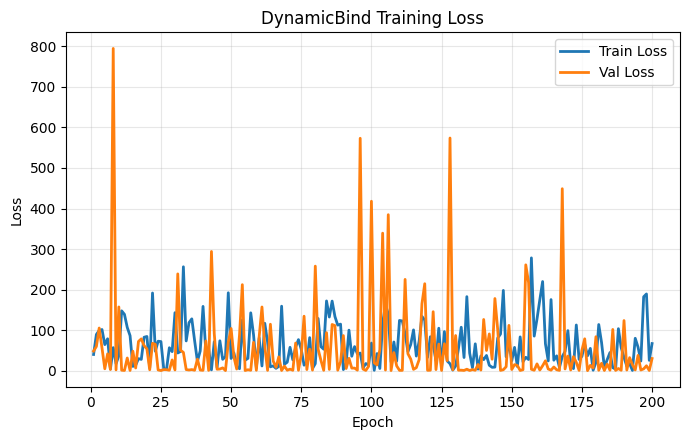

In [10]:
plot_loss_curves(train_loss_history, val_loss_history, title="DynamicBind Training Loss")

## 总结

- 技术路线：DynamicBind 的配体 + 残基六路分数预测路线。
- 教学骨架：`nn.Linear() + nn.ReLU()`。
- 主指标：`RMSD < 2A`。
- 训练损失未下降：`本notebook简化了分子的表征、模型的架构、训练的超参数，因此训练损失难以下降。完整的实现请参考 https://github.com/luwei0917/DynamicBind`